Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

Definição das Funções de Otimização

In [ ]:
def fun_esfera(x): #Função Esfera (unimodal)
    return np.sum(x**2, axis=1)

def fun_rastrigin(x): #Função Rastrigin (multimodal)
    return np.sum((x**2) - 10 * np.cos(2 * np.pi * x) + 10, axis=1)

Busca aleatória Pura

In [ ]:
def busca_aleatoria(func, dim, limite, num_aval, seed):
    """
    Executa a busca aleatória pura.

    Parametros:
    - func: função a ser minimizada
    - dim: numero de variáveis (10)
    - limite: tupla com limite inferior e superior (-5.12, 5.12)
    - num_aval: numero de avaliacoes (100.000)
    - seed: semente para reprodutibilidade
    """
    # Registrando a semente
    np.random.seed(seed)

    low, high = limite

    # Gera todas as soluções candidatas de uma vez
    X = np.random.uniform(low, high, size=(num_aval, dim))

    # Avalia as 100.000 solucoes
    avaliacoes = func(X)

    # Retorna o acumulado das menores solucoes encontradas
    return np.minimum.accumulate(avaliacoes)

Execução

In [ ]:

dim = 10
limite = (-5.12, 5.12)
num_aval = 100000
num_seeds = 29

# Sementes registradas (0 a 29)
seeds = list(range(0, num_seeds + 1))

resultados_esfera = []
resultados_rastrigin = []

print("Executando o experimento para 30 execuções...")

for seed in seeds:

    historico_esfera = busca_aleatoria(fun_esfera, dim, limite, num_aval, seed)
    historico_rastrigin = busca_aleatoria(fun_rastrigin, dim, limite, num_aval, seed)

    resultados_esfera.append(historico_esfera)
    resultados_rastrigin.append(historico_rastrigin)

resultados_esfera = np.array(resultados_esfera)
resultados_rastrigin = np.array(resultados_rastrigin)

# Função auxiliar para calcular e imprimir estatísticas
def print_stats(name, resultados):
    resultado = resultados[:, -1]

    media_val = np.mean(resultado)
    std_val = np.std(resultado, ddof=1) # ddof=1 para desvio padrão amostral
    melhor_val = np.min(resultado)
    pior_val = np.max(resultado) # O "pior" dos melhores resultados de cada run

    print(f"--- Resultados para a função {name} ---")
    print(f"Média (f*): {media_val:.4f}")
    print(f"Desvio Padrão (σ): {std_val:.4f}")
    print(f"Melhor resultado: {melhor_val:.4f}")
    print(f"Pior resultado: {pior_val:.4f}\n")

print_stats("Esfera", resultados_esfera)
print_stats("Rastrigin", resultados_rastrigin)

Executando o experimento para 30 execuções...
--- Resultados para a função Esfera ---
Média (f*): 7.5054
Desvio Padrão (σ): 1.6829
Melhor resultado: 4.8567
Pior resultado: 10.5732

--- Resultados para a função Rastrigin ---
Média (f*): 58.3415
Desvio Padrão (σ): 5.8369
Melhor resultado: 39.4577
Pior resultado: 66.9769



Plotagem dos Gráficos com IC 95%

Gerando os gráficos de convergência...


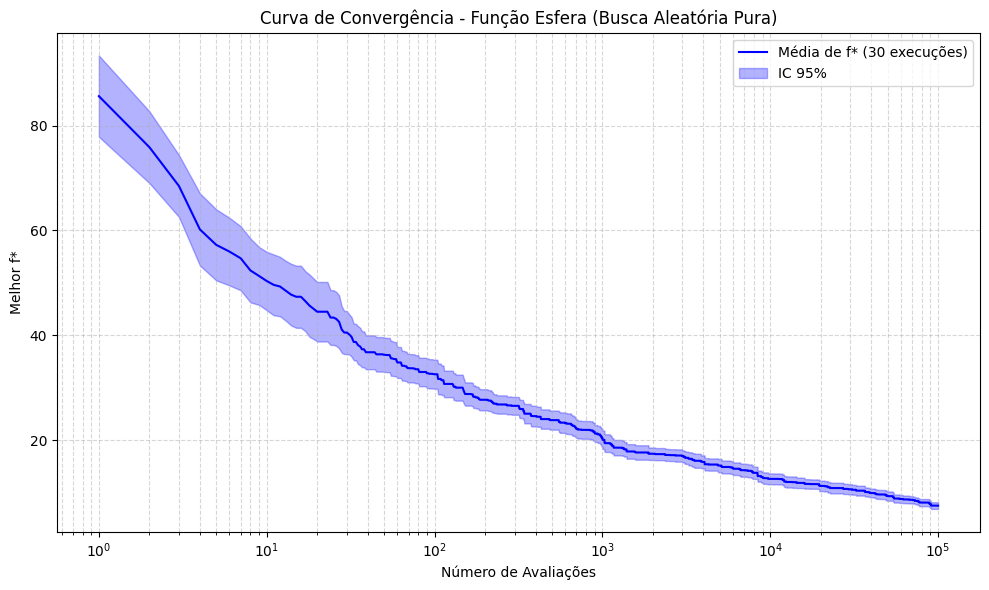

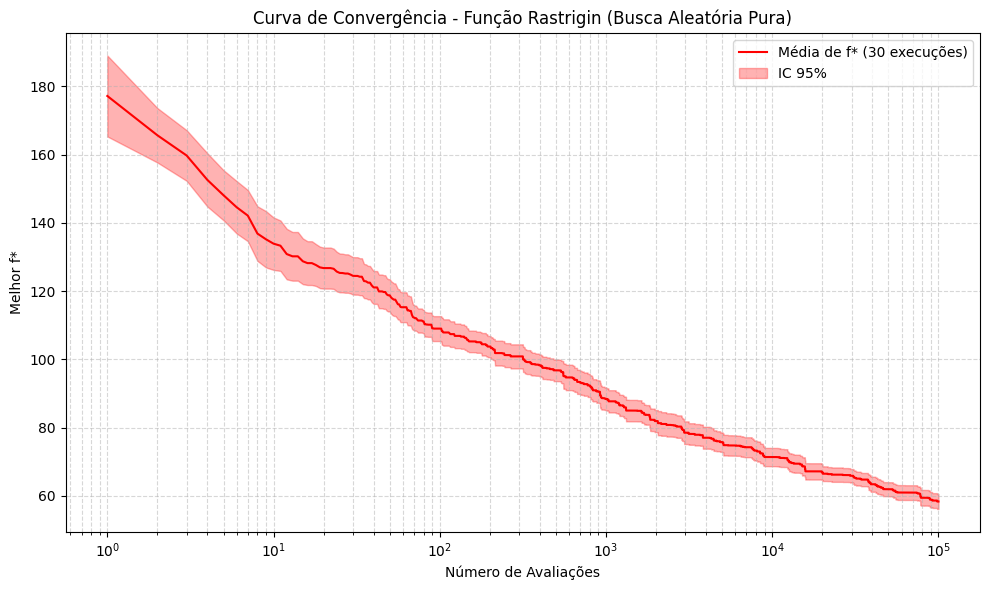

In [ ]:
def plot_graph(name, results_matrix, color):
        mean_curve = np.mean(results_matrix, axis=0)
        std_curve = np.std(results_matrix, axis=0, ddof=1)

        n = results_matrix.shape[0]
        t_val = stats.t.ppf(0.975, df=n-1) # Valor crítico da distribuição t de Student
        ci = t_val * (std_curve / np.sqrt(n))

        plt.figure(figsize=(10, 6))
        x = np.arange(1, num_aval + 1)

        plt.plot(x, mean_curve, label=f'Média de f* (30 execuções)', color=color)
        plt.fill_between(x, mean_curve - ci, mean_curve + ci, color=color, alpha=0.3, label='IC 95%')

        plt.xscale('log')
        plt.xlabel('Número de Avaliações')
        plt.ylabel('Melhor f*')
        plt.title(f'Curva de Convergência - Função {name} (Busca Aleatória Pura)')
        plt.legend()
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

print("Gerando os gráficos de convergência...")
plot_graph("Esfera", resultados_esfera, 'blue')
plot_graph("Rastrigin", resultados_rastrigin, 'red')